# 03 — Classifier validation comparison

This notebook performs the complete model-comparison analysis using validation data only. It
discovers the canonical 24 seed runs (two architectures × four conditions × three seeds), verifies
their completeness, constructs eight architecture–condition ensembles, and evaluates the
preregistered patient-level comparisons. It reads persisted prediction artifacts rather than
training models, and it never opens the held-out test split.

## 1. Discover the canonical 24 run outputs

The repository root, comparison utilities, and active classifier protocol are loaded before scanning
only `results/3_classifiers/seed_runs/`. Discovery is keyed by architecture, condition, and seed and
returns the expected checkpoint, prediction, metric, and completion artifacts for every registered
job. Restricting discovery to the canonical namespace prevents retired experimental trees from
entering the analysis.

In [1]:
from pathlib import Path
import json
import sys
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'configs').is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'notebooks/utility'))
from notebooks.utility.classifier_analysis import (build_all_validation_ensembles, compare_validation,
    discover_experiments, ensemble_metric_table, plot_ensemble_curves, plot_ensemble_overview)
inventory = discover_experiments(ROOT)
sum(row['complete'] for row in inventory), inventory

(24,
 [{'experiment_id': 'maxvit512__real_only__seed17',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 17,
   'directory': '/mnt/MammoDiffusion/MammoDiffusion/results/3_classifiers/seed_runs/maxvit512/real_only/seed_17',
   'training complete': True,
   'validation predictions present': True,
   'validation metrics present': True,
   'checkpoint present': True,
   'complete': True,
   'missing': []},
  {'experiment_id': 'maxvit512__real_only__seed42',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 42,
   'directory': '/mnt/MammoDiffusion/MammoDiffusion/results/3_classifiers/seed_runs/maxvit512/real_only/seed_42',
   'training complete': True,
   'validation predictions present': True,
   'validation metrics present': True,
   'checkpoint present': True,
   'complete': True,
   'missing': []},
  {'experiment_id': 'maxvit512__real_only__seed73',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 73,
   'directory': '

## 2. Enforce run-level completeness

Each inventory row is checked for a compatible completion marker and the artifacts required for
ensemble construction. The explicit list of missing jobs is retained for diagnosis. Downstream
ensemble creation is refused unless all 24 runs are complete, so missing seeds cannot be mistaken for
a valid but smaller uncertainty analysis.

In [2]:
missing_jobs = [row for row in inventory if not row['complete']]
missing_jobs

[]

## 3. Build eight three-seed validation ensembles

For each architecture–condition pair, the code loads exactly three aligned seed prediction tables
and averages their image-level probabilities. Ensemble construction is deterministic and rejects
extra, missing, or repeated seeds. The resulting eight prediction sets isolate the effect of training
condition within each architecture while preserving the registered seed design.

In [3]:
BUILD_ENSEMBLES = True
if BUILD_ENSEMBLES and missing_jobs:
    raise RuntimeError(f'Cannot build 8 ensembles: {len(missing_jobs)} of 24 seed runs are incomplete')
ensembles = build_all_validation_ensembles(ROOT) if BUILD_ENSEMBLES else None
ensembles if ensembles is not None else 'Not yet evaluated — set BUILD_ENSEMBLES=True after all 24 validation outputs exist.'

[{'architecture': 'maxvit512',
  'condition': 'real_only',
  'seeds': [17, 42, 73],
  'method': 'mean_probability',
  'metrics': {'threshold': 0.186832873771588,
   'tp': 54,
   'tn': 254,
   'fp': 110,
   'fn': 19,
   'sensitivity_recall': 0.7397260273972602,
   'specificity': 0.6978021978021978,
   'precision_ppv': 0.32926829268292684,
   'npv': 0.9304029304029304,
   'f1': 0.4556962025316456,
   'accuracy': 0.7048054919908466,
   'balanced_accuracy': 0.718764112599729,
   'mcc': 0.3370660015073126,
   'roc_auc': 0.7778488634653018,
   'pr_auc': 0.5095637601413052,
   'brier_score': 0.11521445022733788,
   'ece': 0.075868844379066,
   'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
    'sensitivity': 0.4794520547945205,
    'achieved_specificity': 0.9010989010989011,
    'threshold': 0.3474189241727193}},
  'confidence_intervals': {'pr_auc': {'percentile_2_5': 0.40762451432689306,
    'percentile_97_5': 0.6097647635035357},
   'roc_auc': {'percentile_2_5': 0.7131313036

## 4. Verify exact prediction alignment

Before probabilities are combined, all seed tables must have identical image/patient keys, labels,
row membership, and validation-manifest identity, with no duplicates, missing values, or non-finite
probabilities. These invariants prevent apparently valid averages from combining predictions for
different samples. Alignment is a hard analytical prerequisite rather than a reporting diagnostic.

In [4]:
alignment_requirements = ['identical patient/image keys', 'identical labels', 'no duplicates', 'no missing rows', 'finite probabilities', 'same validation manifest']
alignment_requirements

['identical patient/image keys',
 'identical labels',
 'no duplicates',
 'no missing rows',
 'finite probabilities',
 'same validation manifest']

## 5. Aggregate predictions at the patient level

Seed probabilities are averaged at image level and then averaged across all available images within
each patient. Labels and identifiers are checked during aggregation, and the patient—not the image—is
the independent unit used by resampling and paired comparisons. This ordering avoids giving patients
with more images unintended statistical weight.

In [5]:
patient_policy = 'mean image probability within patient; patient is the bootstrap unit'
patient_policy

'mean image probability within patient; patient is the bootstrap unit'

## 6. Estimate validation performance and uncertainty

The ensemble table reports patient-level PR-AUC, ROC-AUC, Brier score, and calibration error together
with the protocol-defined confidence intervals. Resampling operates on patients and preserves the
paired structure where required. These intervals quantify sampling uncertainty in this validation
cohort; they do not incorporate distribution shift or external-site uncertainty.

In [6]:
ensemble_table = ensemble_metric_table(ensembles) if ensembles is not None else None
ensemble_table if ensemble_table is not None else 'Not yet evaluated'

,architecture,condition,pr_auc,pr_auc_ci_low,pr_auc_ci_high,roc_auc,brier,ece,delta_pr_auc_vs_real_only,seed_pr_auc_mean,seed_pr_auc_std
0,maxvit512,real_only,0.509564,0.407625,0.609765,0.777849,0.115214,0.075869,0.000000,0.464112,0.032635
1,maxvit512,real_augmented,0.534375,0.437169,0.632962,0.742925,0.117160,0.080297,0.024811,0.469998,0.039636
2,maxvit512,real_plus_best_finetuned_positive,0.556678,0.454821,0.660601,0.786768,0.122451,0.121525,0.047114,0.504719,0.034051
3,maxvit512,real_plus_best_fromscratch_positive,0.548945,0.451897,0.644306,0.755457,0.117208,0.077872,0.039382,0.492060,0.020971
4,mammofm,real_only,0.377118,0.290241,0.473351,0.701528,0.169732,0.208766,0.000000,0.369533,0.017389
5,mammofm,real_augmented,0.384871,0.304323,0.487740,0.747065,0.216360,0.302626,0.007753,0.384370,0.014235
6,mammofm,real_plus_best_finetuned_positive,0.389134,0.301906,0.482300,0.696410,0.159045,0.181102,0.012016,0.373555,0.010774
7,mammofm,real_plus_best_fromscratch_positive,0.358817,0.275478,0.456648,0.711651,0.166181,0.194195,-0.018301,0.359849,0.023298


## 7. Describe variability across random seeds

Per-seed metric summaries expose optimization variability that is hidden by ensemble averaging. Seed
means and standard deviations are reported as descriptive stability measures, whereas ensemble
confidence intervals arise from patient-level sampling uncertainty. Keeping the two sources separate
prevents seed dispersion from being misrepresented as a population confidence interval.

In [7]:
seed_metrics = ({(row['architecture'], row['condition']): row['seed_metrics'] for row in ensembles}
                if ensembles is not None else None)
seed_metrics if seed_metrics is not None else 'Not yet evaluated'

{('maxvit512',
  'real_only'): [{'seed': 17,
   'threshold': 0.4369571805000305,
   'tp': 41,
   'tn': 291,
   'fp': 73,
   'fn': 32,
   'sensitivity_recall': 0.5616438356164384,
   'specificity': 0.7994505494505495,
   'precision_ppv': 0.35964912280701755,
   'npv': 0.9009287925696594,
   'f1': 0.4385026737967915,
   'accuracy': 0.7597254004576659,
   'balanced_accuracy': 0.6805471925334939,
   'mcc': 0.30674618516776825,
   'roc_auc': 0.743940990516333,
   'pr_auc': 0.4392324289341485,
   'brier_score': 0.18897761093893783,
   'ece': 0.24315530314052675,
   'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
    'sensitivity': 0.4383561643835616,
    'achieved_specificity': 0.9120879120879121,
    'threshold': 0.45165908336639404}}, {'seed': 42,
   'threshold': 0.029358504340052605,
   'tp': 51,
   'tn': 253,
   'fp': 111,
   'fn': 22,
   'sensitivity_recall': 0.6986301369863014,
   'specificity': 0.695054945054945,
   'precision_ppv': 0.3148148148148148,
   'npv': 0.92,
 

## 8. Run the preregistered four-condition comparisons

Within each architecture, the three augmentation conditions are compared with the real-only
reference and the two synthetic interventions are compared directly, yielding the prespecified
family of eight patient-level PR-AUC hypotheses. Paired resampling uses the same patients for both
models, and Holm correction controls family-wise error across all eight tests. These validation
results freeze the choices carried into final evaluation; no test information is available here.

In [8]:
RUN_COMPARISONS = BUILD_ENSEMBLES
comparison = compare_validation(ROOT, ensembles) if RUN_COMPARISONS else None
comparison or 'Not yet evaluated — this is validation analysis; Holm correction covers the eight preregistered patient-level PR-AUC comparisons.'

{'split': 'validation',
 'primary_metric': 'pr_auc',
 'patient_level': True,
 'ensembles': [{'architecture': 'maxvit512',
   'condition': 'real_only',
   'seeds': [17, 42, 73],
   'method': 'mean_probability',
   'metrics': {'threshold': 0.186832873771588,
    'tp': 54,
    'tn': 254,
    'fp': 110,
    'fn': 19,
    'sensitivity_recall': 0.7397260273972602,
    'specificity': 0.6978021978021978,
    'precision_ppv': 0.32926829268292684,
    'npv': 0.9304029304029304,
    'f1': 0.4556962025316456,
    'accuracy': 0.7048054919908466,
    'balanced_accuracy': 0.718764112599729,
    'mcc': 0.3370660015073126,
    'roc_auc': 0.7778488634653018,
    'pr_auc': 0.5095637601413052,
    'brier_score': 0.11521445022733788,
    'ece': 0.075868844379066,
    'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
     'sensitivity': 0.4794520547945205,
     'achieved_specificity': 0.9010989010989011,
     'threshold': 0.3474189241727193}},
   'confidence_intervals': {'pr_auc': {'percentile_

## 9. Render and persist the validation evidence

Overview, discrimination, and calibration figures are generated from the verified ensemble objects,
along with the associated tabular summaries and deltas. The plots are read-only views of saved
predictions and preserve the distinction between point estimates, confidence intervals, seed
variability, and adjusted comparisons. They provide the audit trail used to freeze checkpoints and
thresholds before test access.

(<Figure size 1400x500 with 3 Axes>, <Figure size 1600x1000 with 6 Axes>)

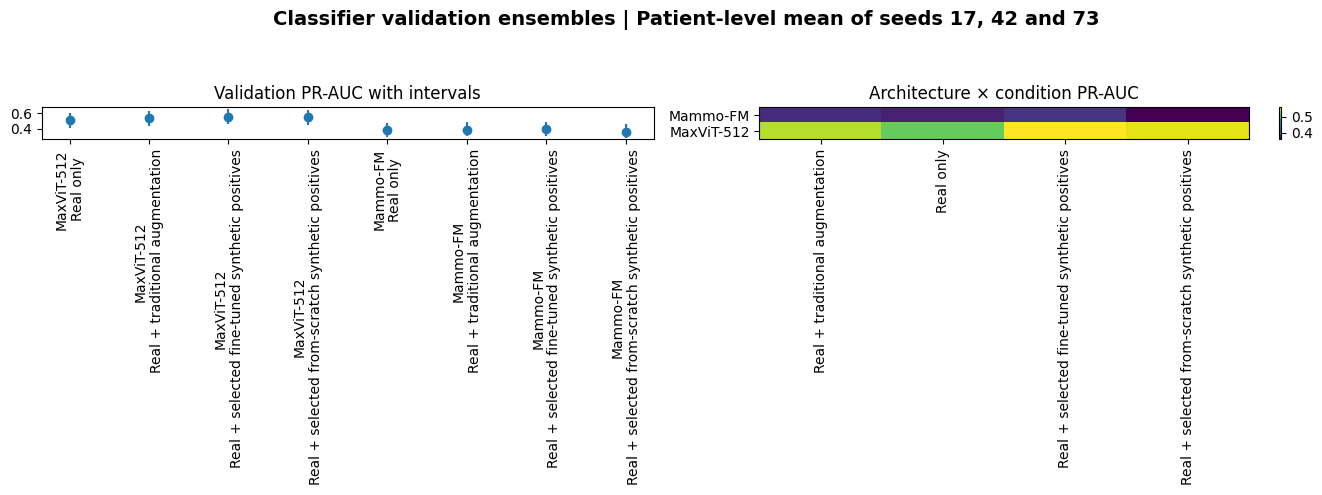

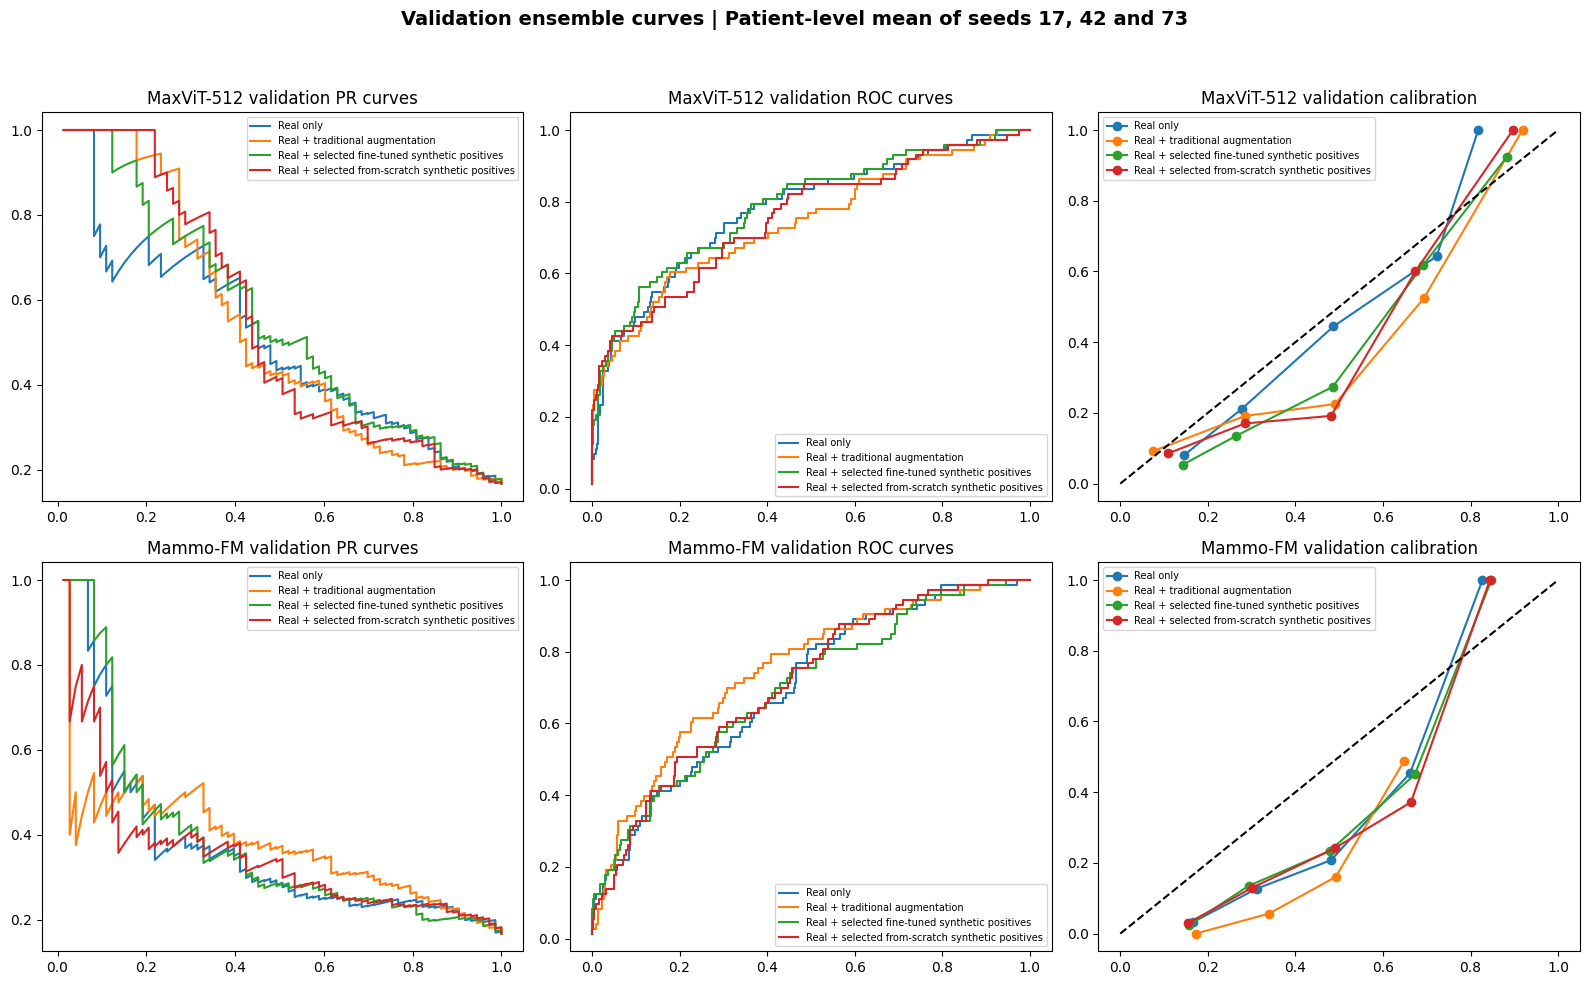

In [9]:
overview_figure = plot_ensemble_overview(ensembles) if ensembles is not None else None
curve_figure = plot_ensemble_curves(ROOT, ensembles) if ensembles is not None else None
(overview_figure, curve_figure) if overview_figure else 'Not yet evaluated — plots include PR-AUC intervals, ROC-AUC/Brier/ECE table, deltas vs real_only, seed mean/SD, heatmap, PR/ROC and calibration curves.'